## Steel Plate Analysis Technical Report
Spencer Mundel and Damon Lewis

### Dataset Description
|                | Steel Plate Dataset |
|----------------|---------------------|
| Instances      | 1941                |
| Unique Classes | 7                   |
| Attributes     | 27                  |

The dataset does not contain any missing classes. Most of the data is continous, with only the steel type values (`TypeOfSteel_A300` and `TypeOfSteel_A400`) being binary classes. 

Overall, the KNN classifier peformed the best, with around 70% accuracy versus ~40% for the other classes.

### EDA Development

See more in depth EDA analysis in `EDA.ipynb`.

In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mysklearn.mypytable import MyPyTable
from mysklearn.myutils import *

In [2]:
CLASSES = ["Pastry","Z_Scratch","K_Scratch","Stains","Dirtiness","Bumps","Other_Faults"]

data = MyPyTable().load_from_file("plate-data.csv")
data = onehot_to_categorical(data, CLASSES)

#### Count Distributions for All Attributes

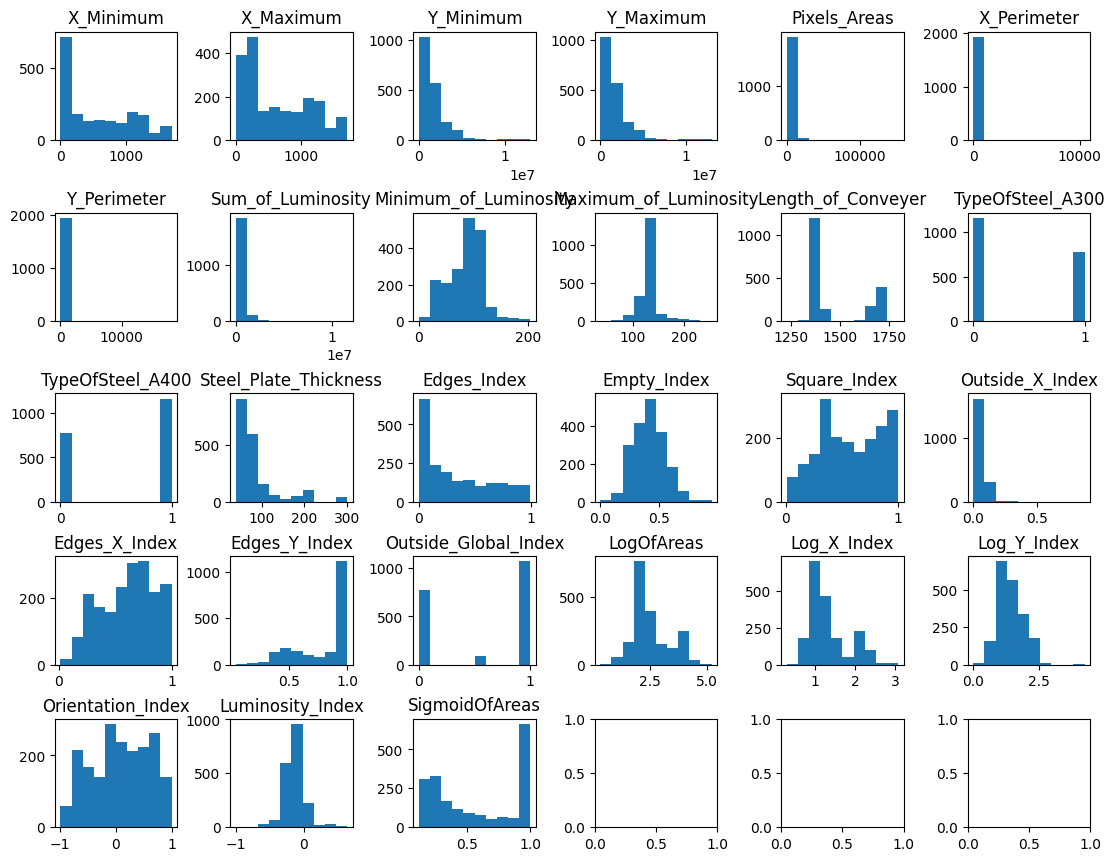

In [3]:
import copy
col_count = 6

tmp_classes = copy.deepcopy(data.column_names)
tmp_classes.remove('Class')
tmp_fig, ax = plt.subplots((len(tmp_classes)//col_count)+1, col_count, layout='constrained', figsize=(8,8))
tmp_fig.set_size_inches(11, 8.5)
for col in range(len(tmp_classes)):
    tmp = ax.flat[col]
    tmp.hist(data.get_column(data.column_names[col]))
    tmp.set_title(data.column_names[col])
plt.savefig('./media/dist.png')

#### Occurrences for Each Class

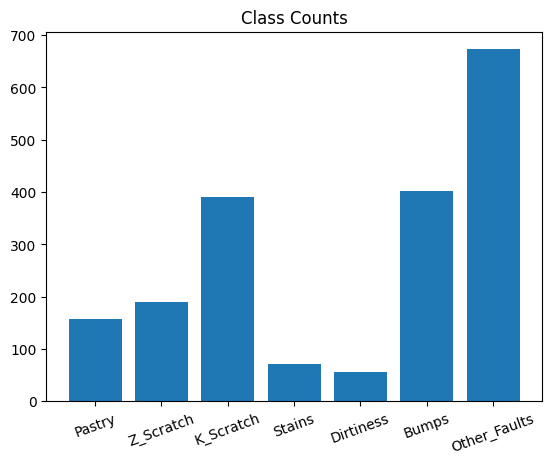

In [4]:
counts = {k: 0 for k in CLASSES}
for result in data.get_column('Class'):
    counts[result]+=1

fig, ax = plt.subplots()
ax.set_title("Class Counts")
ax.bar(counts.keys(), counts.values())
ax.tick_params('x', rotation=20)
fig.savefig('./media/counts.png')

### Model Testing and Results

In [5]:
from copy import deepcopy
from mysklearn import myutils, myclassifiers, mypytable

CLASSES = ["Pastry","Z_Scratch","K_Scratch","Stains","Dirtiness","Bumps","Other_Faults"]
CLASS_HEADER = "Class"

data = mypytable.MyPyTable().load_from_file("plate-data.csv")
data = myutils.onehot_to_categorical(data, CLASSES)
features = deepcopy(data.column_names)
features.pop(features.index(CLASS_HEADER))

'Class'

In [6]:
binned = mypytable.MyPyTable(data.column_names, data.data)

for feature in features:
    if feature == "TypeOfSteel_A300" or feature == "TypeOfSteel_A400":
        continue

    col_values = data.get_column(feature)
    binned_col = myutils.equal_width_bin(col_values, 10)
    binned.replace_column(feature, binned_col)

In [7]:
normalized = mypytable.MyPyTable(data.column_names, data.data)

for feature in features:
    if feature == "TypeOfSteel_A300" or feature == "TypeOfSteel_A400":
        continue

    col_values = data.get_column(feature)
    normalized_col = myutils.normalize_list(col_values)
    normalized.replace_column(feature, normalized_col)

#### Decision Tree

In [8]:
myutils.stratified_kfold_tester(myclassifiers.MyDecisionTreeClassifier(len(features)),
                                binned,
                                CLASS_HEADER,
                                CLASSES,
                                10)

Setup complete
Confusion Matrix
                Pastry    Z_Scratch    K_Scratch    Stains    Dirtiness    Bumps    Other_Faults
------------  --------  -----------  -----------  --------  -----------  -------  --------------
Pastry               0            0           42         0            0        6             110
Z_Scratch            0            0          129         0            0        0              61
K_Scratch            0            0          338         0            0       12              41
Stains               0            0            0         0            0        8              64
Dirtiness            0            0            4         0            0        7              44
Bumps                0            0           48         0            0       22             332
Other_Faults         0            0          158         0            0       44             471
accuracy: 0.836608522852727
precision: 0.1588188383108606
f1 score: 0.17447603524580974
recall:

### KNN

In [9]:
myutils.stratified_kfold_tester(myclassifiers.MyKNeighborsClassifier(n_neighbors=3),
                                normalized,
                                CLASS_HEADER,
                                CLASSES,
                                10)

Setup complete
Confusion Matrix
                Pastry    Z_Scratch    K_Scratch    Stains    Dirtiness    Bumps    Other_Faults
------------  --------  -----------  -----------  --------  -----------  -------  --------------
Pastry              67            3            1         0            1       40              46
Z_Scratch            0          163            4         0            0        7              16
K_Scratch            1            1          369         3            0        5              12
Stains               0            0            0        65            0        2               5
Dirtiness            1            0            0         0           40        5               9
Bumps                6           10            2         6            4      267             107
Other_Faults        32           33           15         7           14      162             410
accuracy: 0.9175682637815559
precision: 0.721620721612343
f1 score: 0.7224927891884348
recall: 

#### KNN with PCA Component Analysis

In [10]:
data_pca = MyPyTable().load_from_file("plate-data-pca.csv")

features = deepcopy(data.column_names)
features.pop(features.index(CLASS_HEADER))

myutils.stratified_kfold_tester(myclassifiers.MyKNeighborsClassifier(n_neighbors=3),
                                data_pca,
                                CLASS_HEADER,
                                CLASSES,
                                10)

Setup complete
Confusion Matrix
                Pastry    Z_Scratch    K_Scratch    Stains    Dirtiness    Bumps    Other_Faults
------------  --------  -----------  -----------  --------  -----------  -------  --------------
Pastry              64            5            0         0            3       39              47
Z_Scratch            2          144            7         0            2       11              24
K_Scratch            1            0          375         2            0        5               8
Stains               0            0            0        66            0        5               1
Dirtiness            2            2            0         0           44        5               2
Bumps               13           10            3         0            7      260             109
Other_Faults        22           35           21         8           11      158             418
accuracy: 0.9160962684919408
precision: 0.717647808753089
f1 score: 0.7183675055986084
recall: 

#### Random Forest

In [11]:
myutils.stratified_kfold_tester(myclassifiers.MyRandomForestClassifier(10, 5, 5),
                                binned,
                                CLASS_HEADER,
                                CLASSES,
                                10)

Setup complete
Confusion Matrix
                Pastry    Z_Scratch    K_Scratch    Stains    Dirtiness    Bumps    Other_Faults
------------  --------  -----------  -----------  --------  -----------  -------  --------------
Pastry               0            0           42         0            0        7             109
Z_Scratch            0            0          129         0            0        2              59
K_Scratch            0            0          338         0            0        9              44
Stains               0            0            0         0            0        9              63
Dirtiness            0            0            4         0            0       10              41
Bumps                0            0           48         0            0       38             316
Other_Faults         0            0          158         0            0       52             463
accuracy: 0.8377861190844189
precision: 0.17030585801348536
f1 score: 0.18234742312914223
recal

#### Clustered Random Forest

In [12]:
myutils.stratified_kfold_tester(myclassifiers.MyClusteredRandomForestClassifier(10, 5, 5, 2),
                                data,
                                CLASS_HEADER,
                                CLASSES,
                                10)

Setup complete
Confusion Matrix
                Pastry    Z_Scratch    K_Scratch    Stains    Dirtiness    Bumps    Other_Faults
------------  --------  -----------  -----------  --------  -----------  -------  --------------
Pastry               0           10           10         0            0       27             111
Z_Scratch            0          122           12         0            0        1              55
K_Scratch            0            0          286         0            0       27              78
Stains               0            0            0         0            0        2              70
Dirtiness            0            0            0         0            0        8              47
Bumps                2           11           10         0            0      103             276
Other_Faults         1           25           32         0            0       61             554
accuracy: 0.8710532126297196
precision: 0.35118147491086454
f1 score: 0.33919722833281
recall: 